# Évaluation du classifieur dogs+cats (132 classes)

Notebook **paramétré** : fonctionne pour n'importe quel checkpoint produit par `python train.py --config-name=config_dogs_cats[_vit]`.

Sections :
1. [Setup](#1-setup) — paramètres + imports
2. [Chargement modèle + dataset](#2-load)
3. [Inférence sur le test set](#3-inference)
4. [Métriques globales](#4-metrics) — top-1 / top-3 / top-5
5. [Dogs vs Cats](#5-dogs-vs-cats) — split par espèce
6. [Per-class accuracy](#6-per-class) — top-10 pires / top-10 meilleures races
7. [Matrice de confusion](#7-confusion) — heatmap + paires les plus confondues
8. [Calibration (ECE)](#8-calibration)
9. [Galerie d'erreurs](#9-errors) — images mal prédites
10. [Courbes d'entraînement](#10-tensorboard) — depuis TensorBoard

## 1. Setup <a id='1-setup'></a>

**Modifie ces deux variables** pour changer de modèle :

In [1]:
# ───────── PARAMÈTRES ─────────
# Chemins relatifs à la racine du projet (le notebook fait os.chdir vers la racine plus bas).
MODEL_NAME = 'vit'    # 'resnet50' ou 'vit'
# ViT entraîné sur Stanford Dogs + Oxford-IIIT cats (132 classes), best epoch=67 val_acc=0.91
CKPT_PATH  = 'experiments/vit_dogs_cats/checkpoints/epoch=epoch=67-val_acc=val/acc=0.91-step=19516.ckpt'
EXPERIMENT_DIR = 'experiments/vit_dogs_cats'  # contient checkpoints/, splits/, tensorboard/
BATCH_SIZE = 32
TOP_K      = 5
# ──────────────────────────────

import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
# We may be launched from notebooks/ (Jupyter UI) or from the project root (nbconvert). Detect both.
if (ROOT / 'src' / 'bcs_pipeline').is_dir():
    pass  # already at project root
elif (ROOT.parent / 'src' / 'bcs_pipeline').is_dir():
    ROOT = ROOT.parent
else:
    raise RuntimeError(f'Cannot locate project root from cwd={ROOT}')

sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)  # so relative CKPT_PATH / EXPERIMENT_DIR resolve from the project root

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

from bcs_pipeline.data.combined_classification_datamodule import CombinedDogsCatsDataModule
from bcs_pipeline.inference.classification import load_classification_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Project root: {ROOT}')
print(f'Checkpoint  : {CKPT_PATH}')
print(f'Model       : {MODEL_NAME}')

Device: cuda
Project root: /home/SPeillet/bcs_determination
Checkpoint  : experiments/vit_dogs_cats/checkpoints/epoch=epoch=67-val_acc=val/acc=0.91-step=19516.ckpt
Model       : vit


## 2. Chargement modèle + dataset <a id='2-load'></a>

In [2]:
ckpt_abs = (ROOT / CKPT_PATH).resolve()
exp_dir_abs = (ROOT / EXPERIMENT_DIR).resolve()
assert ckpt_abs.is_file(), f'Checkpoint introuvable : {ckpt_abs}'

model = load_classification_model(
    str(ckpt_abs),
    model_name=MODEL_NAME,
    num_classes=132,
    device=torch.device(DEVICE),
)
model.eval()

# Reuse the SAME splits used during training (same hash → same indices).
# Pointing split_dir to the experiment folder reuses the manifest produced at train time.
SPLIT_DIR = str(exp_dir_abs / 'splits')

dm = CombinedDogsCatsDataModule(
    stanford_data_dir='data/stanford_dogs/images',
    oxford_data_dir='data/Oxford-IIIT_pet_dataset',
    batch_size=BATCH_SIZE, num_workers=4, image_size=224,
    val_split=0.1, test_split=0.1, seed=42,
    split_dir=SPLIT_DIR,
)
dm.prepare_data(); dm.setup()
class_names = dm.classes
is_cat = np.array([i >= 120 for i in range(132)])  # idx 120-131 = cats
print(f'Classes: {len(class_names)} ({(~is_cat).sum()} chiens + {is_cat.sum()} chats)')
print(f'Test set: {len(dm.test_indices)} images')

Classes: 132 (120 chiens + 12 chats)
Test set: 2296 images


## 3. Inférence sur le test set <a id='3-inference'></a>

In [3]:
all_logits, all_labels = [], []
loader = dm.test_dataloader()
with torch.no_grad():
    for xb, yb in tqdm(loader, desc='Inference'):
        xb = xb.to(DEVICE)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_labels.append(yb)
logits = torch.cat(all_logits)        # [N, 132]
labels = torch.cat(all_labels).numpy() # [N]
probs  = F.softmax(logits, dim=1).numpy()
preds  = probs.argmax(axis=1)
print(f'Done. Logits shape: {logits.shape}')

Inference:   0%|          | 0/72 [00:00<?, ?it/s]

Done. Logits shape: torch.Size([2296, 132])


## 4. Métriques globales <a id='4-metrics'></a>

In [4]:
def topk_accuracy(probs, labels, k):
    topk = np.argsort(-probs, axis=1)[:, :k]
    return (topk == labels[:, None]).any(axis=1).mean()

for k in (1, 3, 5):
    print(f'Top-{k} accuracy : {topk_accuracy(probs, labels, k)*100:6.2f}%')

Top-1 accuracy :  89.63%
Top-3 accuracy :  98.34%
Top-5 accuracy :  99.17%


## 5. Dogs vs Cats <a id='5-dogs-vs-cats'></a>

Permet d'identifier si le modèle est globalement bon mais foire sur les chats (peu représentés), ou inversement.

In [5]:
labels_is_cat = labels >= 120
preds_is_cat  = preds  >= 120

# Species-level confusion (binary)
print('\n── Espèce (binaire) ─────────────────────')
print(f'  Espèce correctement identifiée : {(labels_is_cat == preds_is_cat).mean()*100:.2f}%')
print(f'  Chiens classés comme chats     : {(~labels_is_cat & preds_is_cat).sum()} / {(~labels_is_cat).sum()}')
print(f'  Chats classés comme chiens     : {(labels_is_cat & ~preds_is_cat).sum()} / {labels_is_cat.sum()}')

# Per-species top-1 accuracy
print('\n── Top-1 accuracy par espèce ────────────')
for name, mask in [('Chiens (120 races)', ~labels_is_cat), ('Chats  (12 races) ', labels_is_cat)]:
    acc = (preds[mask] == labels[mask]).mean() * 100
    print(f'  {name} : {acc:6.2f}%   ({mask.sum()} images)')


── Espèce (binaire) ─────────────────────
  Espèce correctement identifiée : 99.96%
  Chiens classés comme chats     : 0 / 2059
  Chats classés comme chiens     : 1 / 237

── Top-1 accuracy par espèce ────────────
  Chiens (120 races) :  89.27%   (2059 images)
  Chats  (12 races)  :  92.83%   (237 images)


## 6. Per-class accuracy <a id='6-per-class'></a>

In [6]:
per_class_acc = np.zeros(132)
per_class_n   = np.zeros(132, dtype=int)
for c in range(132):
    mask = labels == c
    per_class_n[c] = mask.sum()
    if mask.any():
        per_class_acc[c] = (preds[mask] == c).mean()

df = pd.DataFrame({
    'class': class_names,
    'is_cat': is_cat,
    'n_test': per_class_n,
    'accuracy': per_class_acc,
}).sort_values('accuracy', ascending=False).reset_index(drop=True)

print('── Top 10 meilleures races ──')
print(df.head(10).to_string(index=False))
print('\n── Top 10 pires races ──')
print(df.tail(10)[::-1].to_string(index=False))

── Top 10 meilleures races ──
             class  is_cat  n_test  accuracy
  Japanese_spaniel   False      19       1.0
            borzoi   False      15       1.0
        bloodhound   False      19       1.0
          papillon   False      20       1.0
     affenpinscher   False      15       1.0
           basenji   False      21       1.0
               pug   False      20       1.0
Bedlington_terrier   False      18       1.0
    Border_terrier   False      17       1.0
        Weimaraner   False      16       1.0

── Top 10 pires races ──
                         class  is_cat  n_test  accuracy
                    Eskimo_dog   False      15  0.266667
              miniature_poodle   False      15  0.466667
            standard_schnauzer   False      16  0.562500
                  Walker_hound   False      15  0.600000
              English_foxhound   False      16  0.625000
American_Staffordshire_terrier   False      16  0.625000
          Bouvier_des_Flandres   False      15  0.

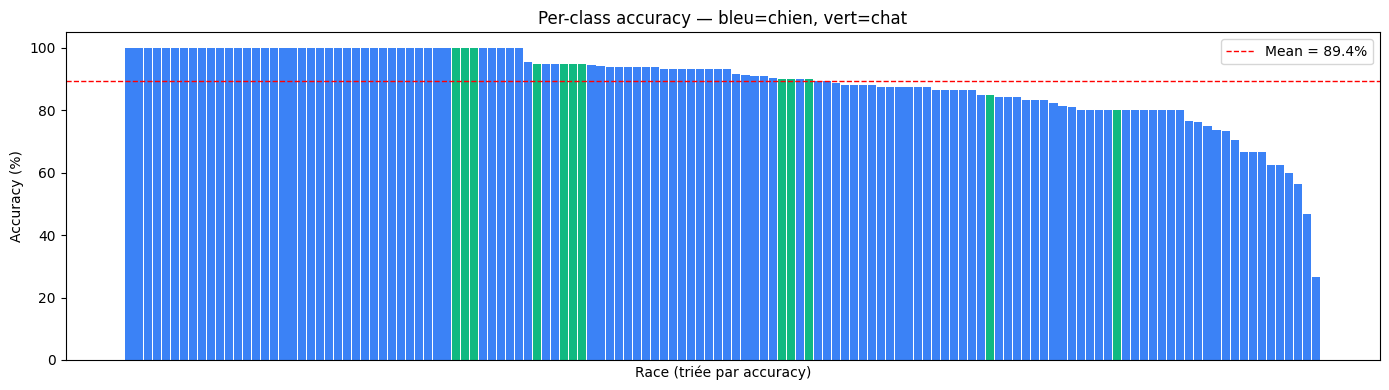

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
df_sorted = df.sort_values('accuracy', ascending=False).reset_index(drop=True)
colors = ['#10b981' if c else '#3b82f6' for c in df_sorted['is_cat']]
ax.bar(range(132), df_sorted['accuracy']*100, color=colors, width=0.9)
ax.axhline(per_class_acc.mean()*100, color='red', ls='--', lw=1, label=f'Mean = {per_class_acc.mean()*100:.1f}%')
ax.set(xlabel='Race (triée par accuracy)', ylabel='Accuracy (%)',
       title='Per-class accuracy — bleu=chien, vert=chat')
ax.set_xticks([]); ax.legend()
plt.tight_layout(); plt.show()

## 7. Matrice de confusion <a id='7-confusion'></a>

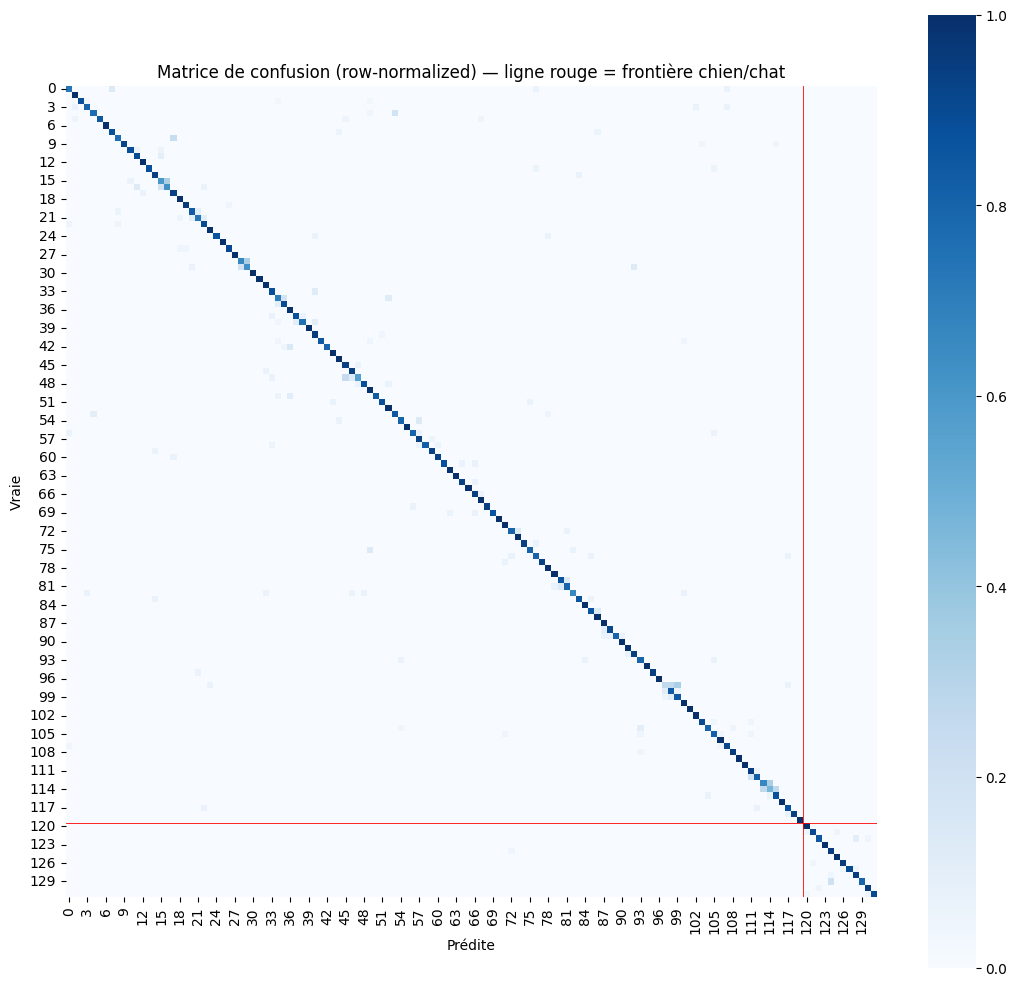

In [8]:
cm = confusion_matrix(labels, preds, labels=list(range(132)))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)  # row-normalize

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(cm_norm, cmap='Blues', vmin=0, vmax=1, square=True, cbar=True, ax=ax)
# Highlight the dog/cat boundary
ax.axhline(120, color='red', lw=0.6); ax.axvline(120, color='red', lw=0.6)
ax.set(xlabel='Prédite', ylabel='Vraie',
       title='Matrice de confusion (row-normalized) — ligne rouge = frontière chien/chat')
plt.tight_layout(); plt.show()

In [9]:
# Top-20 des paires (vrai → prédit) les plus confondues, hors diagonale
off = cm.copy()
np.fill_diagonal(off, 0)
pairs = []
for i in range(132):
    for j in range(132):
        if off[i, j] > 0:
            pairs.append((off[i, j], class_names[i], class_names[j]))
pairs.sort(reverse=True)
print('── 20 paires les plus confondues (vraie → prédite) ──')
for n, a, b in pairs[:20]:
    print(f'  {n:3d}  {a:35s} → {b}')

── 20 paires les plus confondues (vraie → prédite) ──
    5  toy_poodle                          → miniature_poodle
    5  Walker_hound                        → English_foxhound
    5  Staffordshire_bullterrier           → American_Staffordshire_terrier
    5  Eskimo_dog                          → Siberian_husky
    4  standard_schnauzer                  → miniature_schnauzer
    4  miniature_poodle                    → toy_poodle
    4  miniature_poodle                    → standard_poodle
    4  Shih-Tzu                            → Lhasa
    4  Russian_Blue                        → British_Shorthair
    4  Rhodesian_ridgeback                 → redbone
    4  Eskimo_dog                          → malamute
    3  Norfolk_terrier                     → Norwich_terrier
    3  English_foxhound                    → Walker_hound
    3  Cardigan                            → Pembroke
    3  Australian_terrier                  → Yorkshire_terrier
    3  American_Staffordshire_terrier      → St

## 8. Calibration (ECE) <a id='8-calibration'></a>

Mesure si les probabilités prédites correspondent vraiment à la fréquence d'erreur — un modèle sur-confiant donne 90% de confiance mais se trompe 30% du temps.

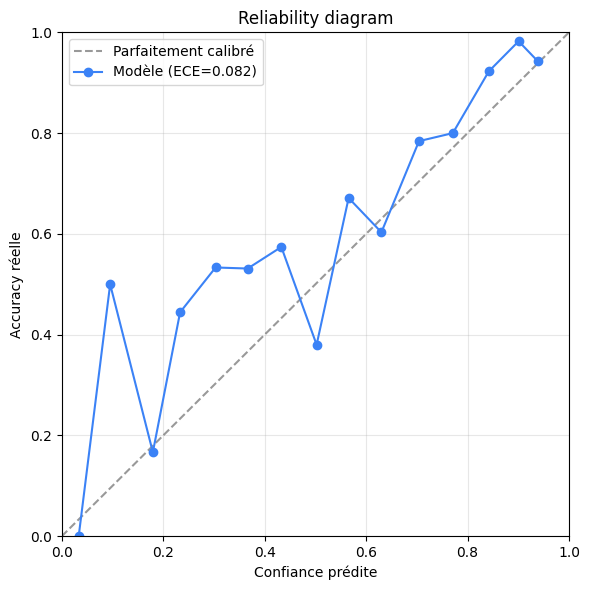

ECE (Expected Calibration Error) : 0.0817  (plus c'est bas, mieux c'est)


In [10]:
conf = probs.max(axis=1)
correct = (preds == labels).astype(float)
n_bins = 15
bins = np.linspace(0, 1, n_bins + 1)
ece = 0.0
bin_acc, bin_conf, bin_count = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (conf >= lo) & (conf < hi)
    if mask.sum() > 0:
        a = correct[mask].mean()
        c = conf[mask].mean()
        ece += (mask.sum() / len(conf)) * abs(a - c)
        bin_acc.append(a); bin_conf.append(c); bin_count.append(mask.sum())
    else:
        bin_acc.append(0); bin_conf.append((lo+hi)/2); bin_count.append(0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Parfaitement calibré')
ax.plot(bin_conf, bin_acc, 'o-', color='#3b82f6', label=f'Modèle (ECE={ece:.3f})')
ax.set(xlabel='Confiance prédite', ylabel='Accuracy réelle', xlim=(0,1), ylim=(0,1),
       title='Reliability diagram')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'ECE (Expected Calibration Error) : {ece:.4f}  (plus c\'est bas, mieux c\'est)')

## 9. Galerie d'erreurs <a id='9-errors'></a>

Affiche les erreurs les plus *confiantes* — souvent les cas les plus instructifs (le modèle est sûr de lui ET se trompe).

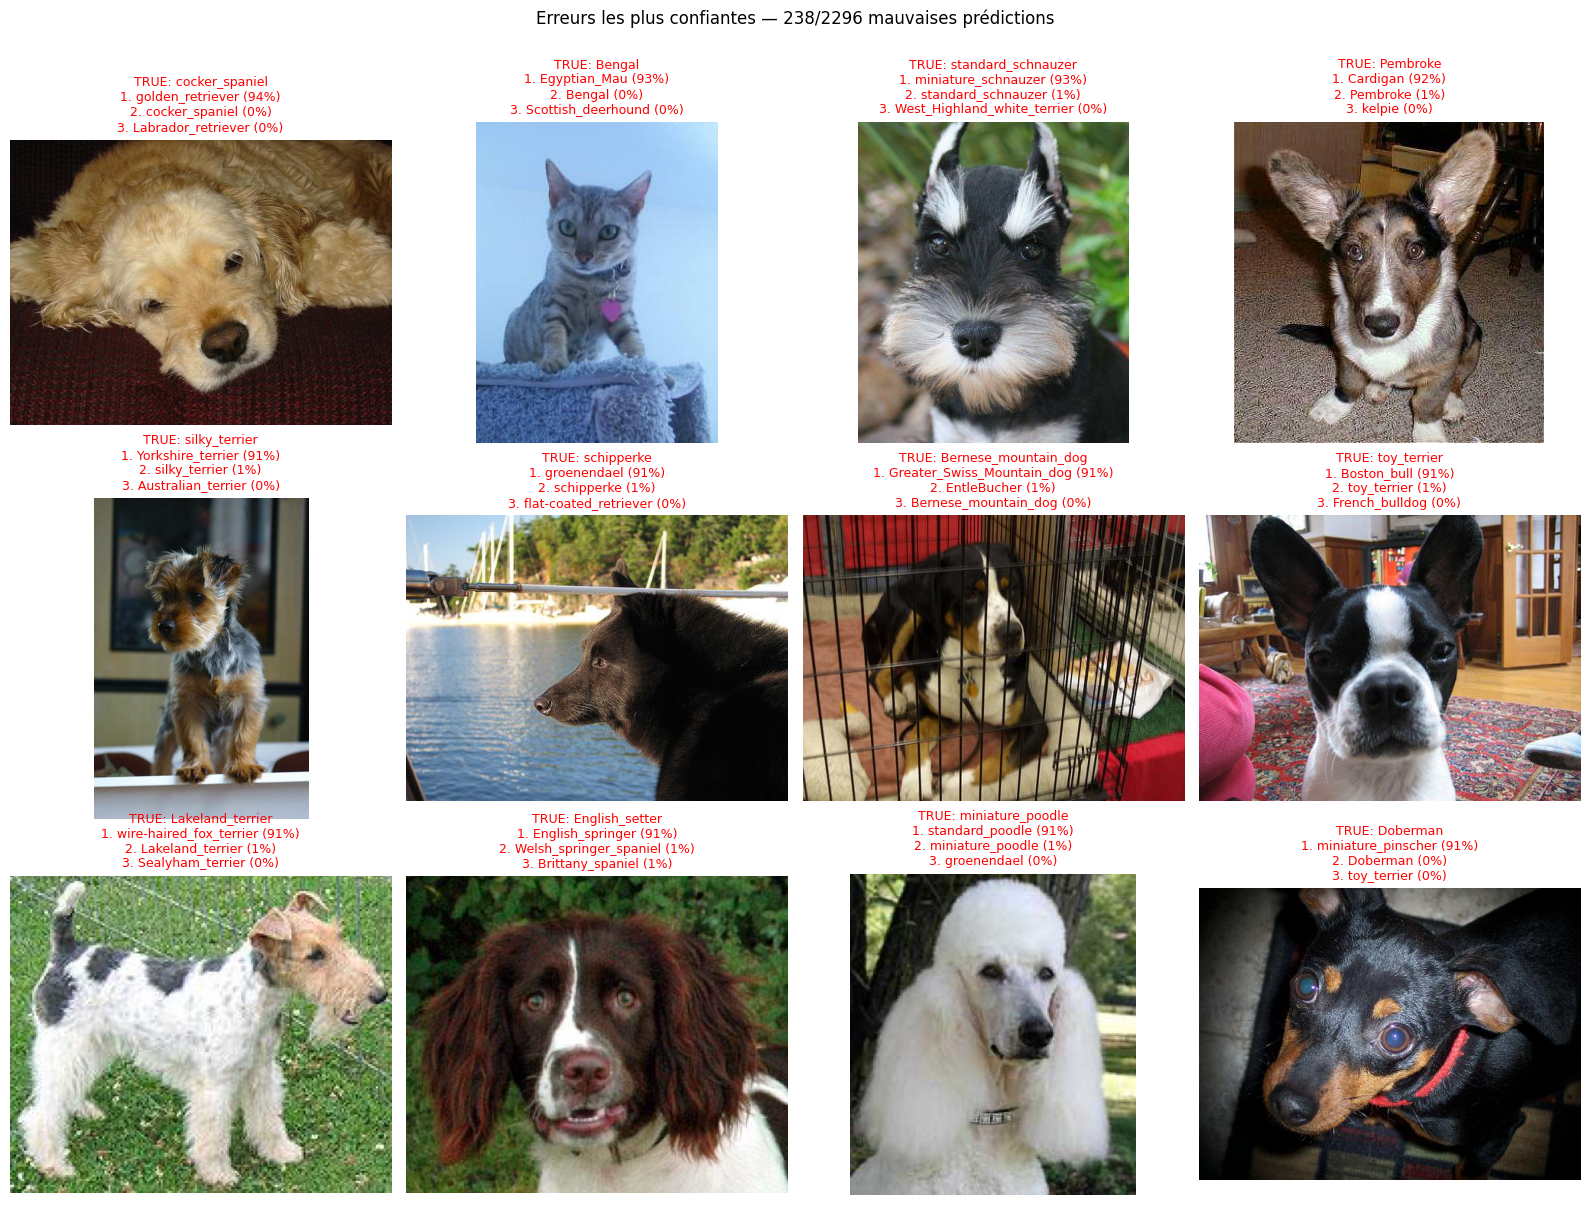

In [11]:
wrong = np.where(preds != labels)[0]
wrong_conf = conf[wrong]
wrong_sorted = wrong[np.argsort(-wrong_conf)]

# Map test indices back to file paths via the underlying samples list
full = dm.data_test.subset.dataset  # _CombinedSamplesDataset
test_idx_to_sample = {i: full.samples[dm.test_indices[i]] for i in range(len(dm.test_indices))}

n_show = 12
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, i in zip(axes.flat, wrong_sorted[:n_show]):
    img_path, true_lbl = test_idx_to_sample[i]
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img); ax.axis('off')
    top3 = np.argsort(-probs[i])[:3]
    title = f'TRUE: {class_names[true_lbl]}\n'
    title += '\n'.join(f'{r+1}. {class_names[c]} ({probs[i][c]*100:.0f}%)' for r, c in enumerate(top3))
    ax.set_title(title, fontsize=9, color='red' if top3[0] != true_lbl else 'green')
plt.suptitle(f'Erreurs les plus confiantes — {len(wrong)}/{len(labels)} mauvaises prédictions', y=1.0)
plt.tight_layout(); plt.show()

## 10. Courbes d'entraînement (TensorBoard) <a id='10-tensorboard'></a>

Montre l'évolution train/val sur tout l'entraînement. Skip cette cellule si tu n'as pas les events files.

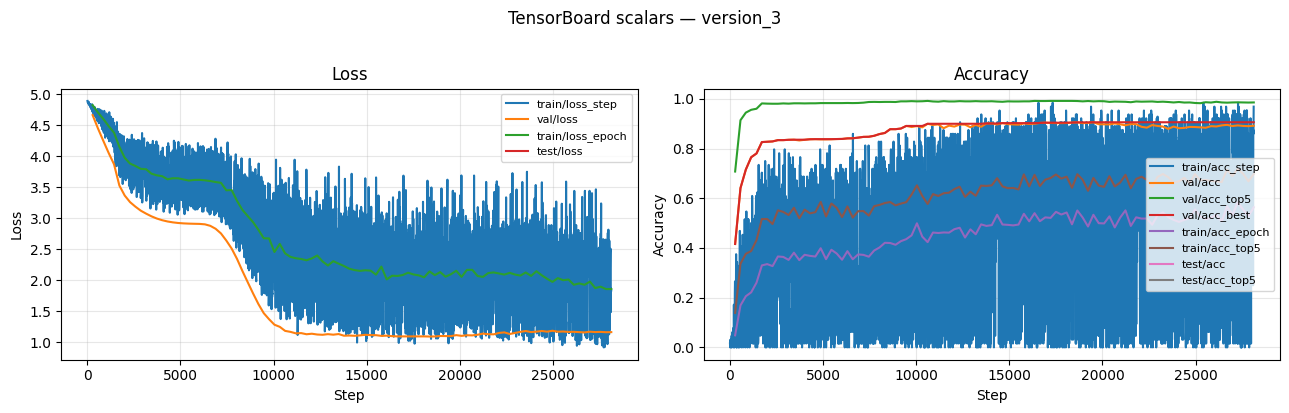

In [12]:
try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    tb_dirs = list(exp_dir_abs.rglob('events.out.tfevents.*'))
    # The largest event file is the actual training run; tiny ones are post-fit eval events.
    tb_dirs = sorted(tb_dirs, key=lambda p: p.stat().st_size, reverse=True)
    if not tb_dirs:
        print(f'Aucun event TB trouvé sous {exp_dir_abs}')
    else:
        ea = EventAccumulator(str(tb_dirs[0].parent)); ea.Reload()
        scalars_to_plot = [t for t in ea.Tags()['scalars'] if 'acc' in t.lower() or 'loss' in t.lower()]
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        for tag in scalars_to_plot:
            events = ea.Scalars(tag)
            steps = [e.step for e in events]; vals = [e.value for e in events]
            ax = axes[0] if 'loss' in tag.lower() else axes[1]
            ax.plot(steps, vals, label=tag)
        for ax, t in zip(axes, ['Loss', 'Accuracy']):
            ax.set(xlabel='Step', ylabel=t, title=t); ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.suptitle(f'TensorBoard scalars — {tb_dirs[0].parent.name}', y=1.02)
        plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Skipping TB plot: {e}')